# L4 Fields comparisons : allnadirs vs allnadirs+swot
- plot KE with several L4 fields

In [4]:
import os
from glob import glob

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.geodesic import Geodesic

import numpy as np
import xarray as xr
import pandas as pd

import jax
import jax.numpy as jnp
import jaxparrow as jpw

%matplotlib inline
from matplotlib import pyplot as plt

path_save_plot = './save_plots/save_plots_2024-06-12_DrifterL1DataExploration'
drifters_directory = '/home/bouxdecl/Documents/data/all_drifters_sharing'

bbox_drifters = [0, 13.5, 36.5, 44]
bbox_mediterranea = [-5.8, 36.5, 30, 44.5]

#### func

In [5]:
def _add_one_Tgrid_velocity(ds, u, axis, padding):
    u_t = jpw.tools.operators.interpolation(jnp.copy(ds[u].values), axis=axis, padding=padding)
    ds[str(u)+'_t'] = ds[u].copy(data=u_t)
    return ds

def add_Tgrid_velocities(ds):

    ds = _add_one_Tgrid_velocity(ds, 'u_geos', axis=1, padding='left')
    ds = _add_one_Tgrid_velocity(ds, 'v_geos', axis=0, padding='left')

    ds = _add_one_Tgrid_velocity(ds, 'u_var', axis=1, padding='left')
    ds = _add_one_Tgrid_velocity(ds, 'v_var', axis=0, padding='left')

    return ds


In [6]:
def restrain_domain(ds, min_lon, max_lon, min_lat, max_lat):
    extend = (min_lon <= ds.longitude) & (ds.longitude <= max_lon) & (min_lat <= ds.latitude) & (ds.latitude <= max_lat)
    in_biscay = (ds.longitude <= -0.1462) & (ds.latitude >= 43.2744)
    in_blacksea = (ds.longitude >= 27.4437) & (ds.latitude >= 40.9088)
    
    mask = extend & ~(in_biscay | in_blacksea) # exclude biscay and black sea
    return ds.where(mask, drop=True)


def plot2d(lon, lat, data, bbox: tuple=bbox_mediterranea, cmap='Oranges', center_bar=False, fraction_cbar=0.033,  title= None, save_name=None):
    # Set up the figure and map projection
    fig = plt.figure(tight_layout=True, figsize=(8, 8))
    crs = ccrs.PlateCarree()
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
    _ = ax.gridlines(draw_labels=True,)

    # Add land feature for better visualization
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.COASTLINE)

    # Set the map extent
    ax.set_extent(bbox, crs=crs)

    # Plot the density of points
    if center_bar:
        vmax = np.nanmax(np.abs(data))
        vmin = - vmax
    else:
        vmax = np.nanmax(data)
        vmin = np.nanmin(data)

    mesh = ax.pcolormesh(lon, lat, data, transform=crs, cmap=cmap, vmin=vmin, vmax=vmax)

    # Add a color bar to show the density scale
    cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', fraction=fraction_cbar, pad=0.08)
    #cbar.set_label('Density')


    if title:
        ax.set_title(title)
        
    ### SAVE
    if save_name:
        ax.set_title(save_name)
        save_name = save_name
        plt.savefig(os.path.join(path_save_plot,save_name), bbox_inches='tight', dpi = 300)

In [7]:
# MIOST field data

path = '/home/bouxdecl/Documents/my_python/MIOST/data_RESULTS/'
ds_nadir = xr.open_dataset(os.path.join(path, 'results_MIOST_allnadirs-alg_GOOD.nc'))
ds_swot = xr.open_dataset(os.path.join(path, 'results_MIOST_allnadirs-alg_and_SWOT_GOOD.nc'))

# add t-grid values for velocities

ds_nadir = add_Tgrid_velocities(ds_nadir)
ds_swot  = add_Tgrid_velocities(ds_swot)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


#### KE moyen

In [8]:
# dataset span
print(ds_nadir.time.min().values)
print(ds_nadir.time.max().values)

2023-03-28T00:00:00.000000000
2023-07-10T00:00:00.000000000


In [9]:
# reduce time span
start_time = '2020-05-01'
end_time = '2024-05-31'

#choose between bbox_mediterranea & bbox_drifters
bbox = bbox_drifters

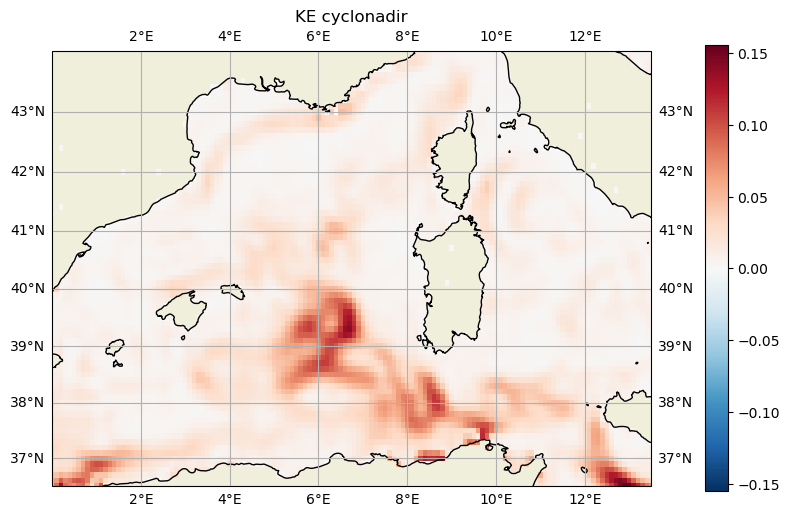

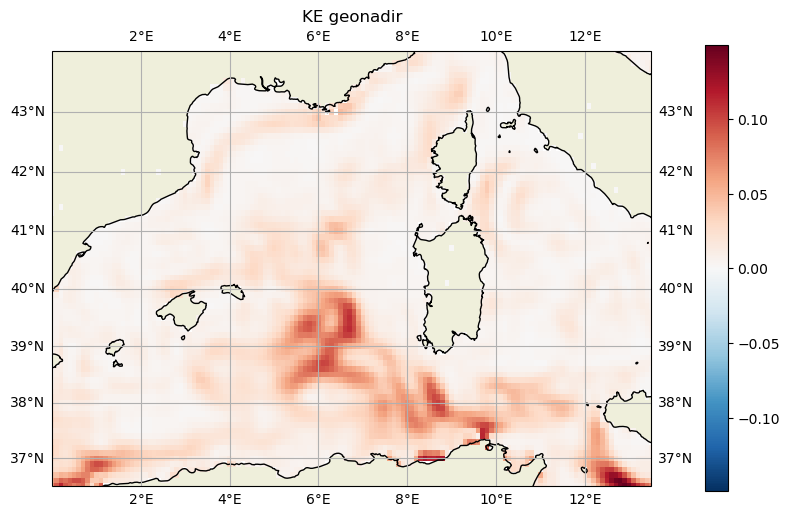

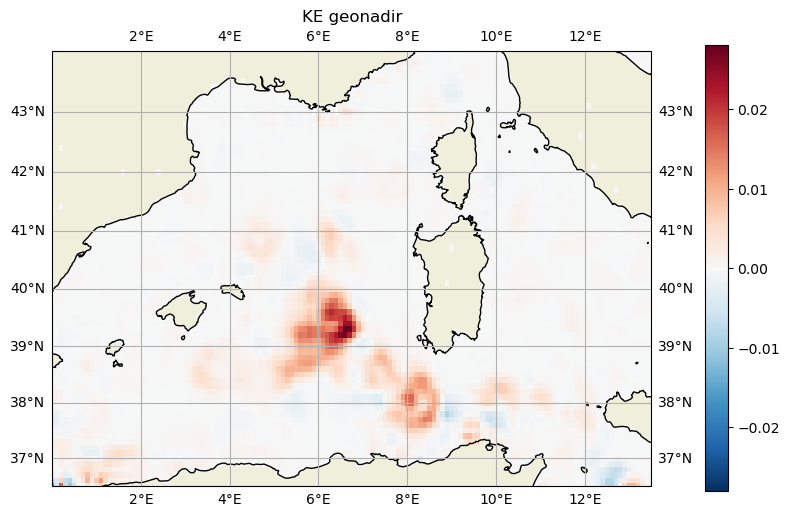

In [10]:

# NADIR
ds = ds_nadir

#select data
ds = restrain_domain(ds, *bbox)
ds = ds.sel(time=slice(start_time, end_time))

#get data
lon, lat = ds.longitude, ds.latitude

KE_var = ( ds.u_var_t**2 + ds.v_var_t**2   ).mean(dim='time') 
KE_geo = ( ds.u_geos_t**2 + ds.v_geos_t**2 ).mean(dim='time') 

#plot data
plot2d(lon, lat, KE_var, bbox, cmap='RdBu_r', center_bar=True, title='KE cyclonadir')
plot2d(lon, lat, KE_geo, bbox, cmap='RdBu_r', center_bar=True, title='KE geonadir')
plot2d(lon, lat, KE_var - KE_geo, bbox, cmap='RdBu_r', center_bar=True, title='KE geonadir')
#plot2d(lon, lat, (KE_var - KE_geo)/np.nanstd(KE_geo), bbox, cmap='RdBu_r', center_bar=True, title='KE geonadir\nnormalization by std(KE_geo) = {:.2e}'.format(np.nanstd(KE_geo)))

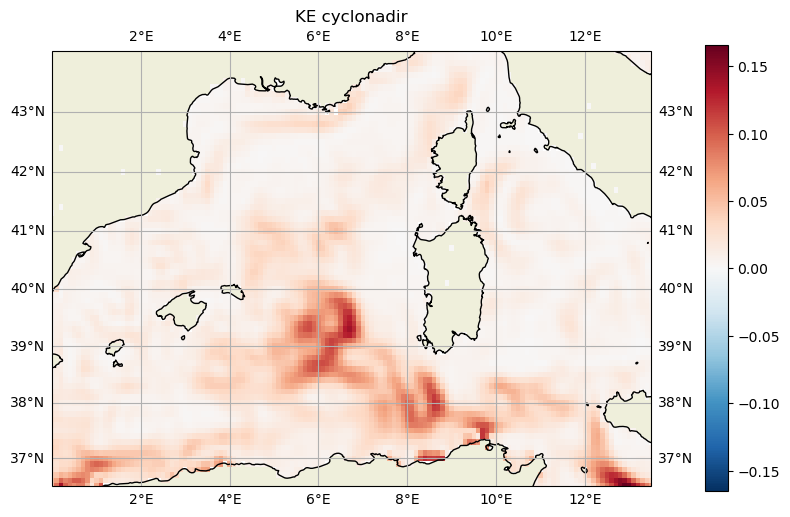

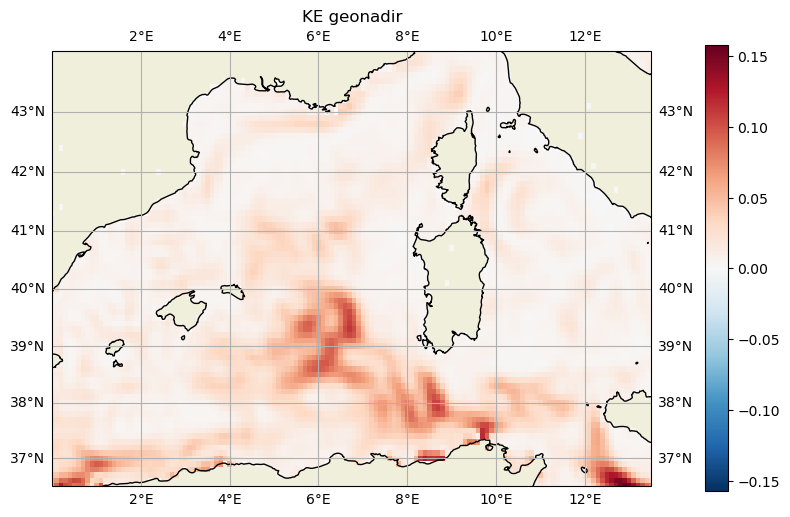

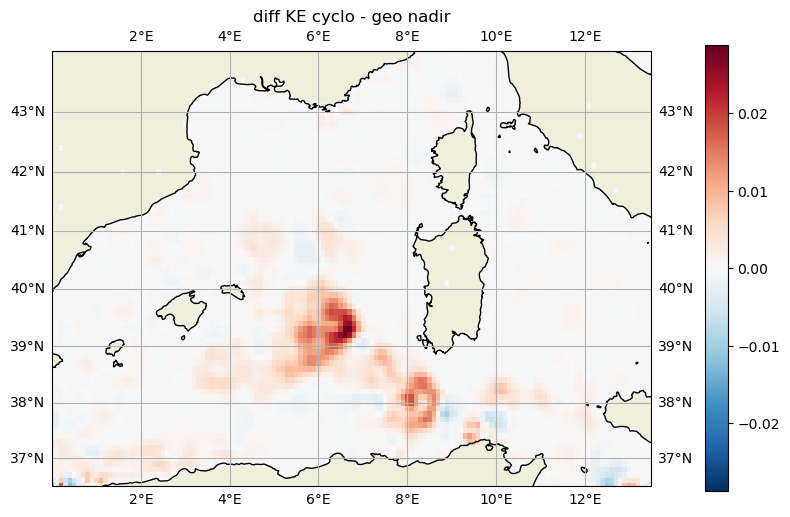

In [11]:

# SWOT
ds = ds_swot 


#select data
ds = restrain_domain(ds, *bbox)
ds = ds.sel(time=slice(start_time, end_time))

#get data
lon, lat = ds.longitude, ds.latitude

KE_var = ( ds.u_var_t**2 + ds.v_var_t**2   ).mean(dim='time') 
KE_geo = ( ds.u_geos_t**2 + ds.v_geos_t**2 ).mean(dim='time') 

#plot data
plot2d(lon, lat, KE_var, bbox, cmap='RdBu_r', center_bar=True, title='KE cyclonadir')
plot2d(lon, lat, KE_geo, bbox, cmap='RdBu_r', center_bar=True, title='KE geonadir')
plot2d(lon, lat, (KE_var - KE_geo), bbox, cmap='RdBu_r', center_bar=True, title='diff KE cyclo - geo nadir')

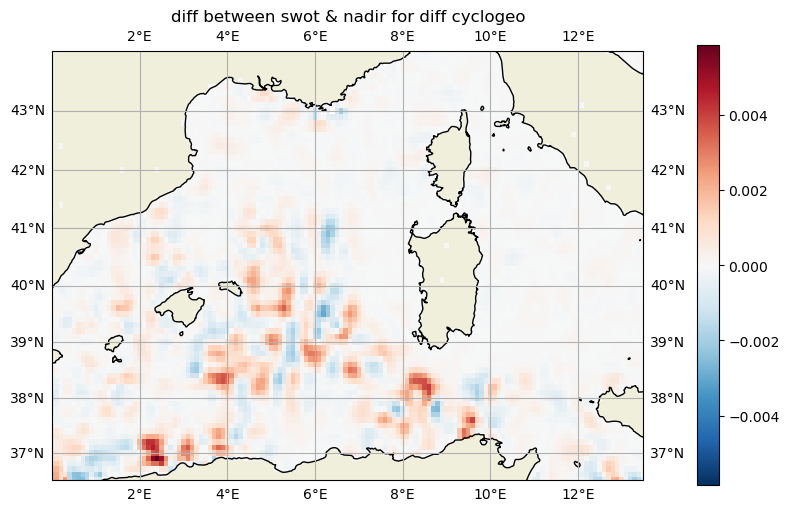

In [12]:
ds = ds_nadir
ds = restrain_domain(ds, *bbox)
ds = ds.sel(time=slice(start_time, end_time))
KE_var_nadir = ( ds.u_var_t**2 + ds.v_var_t**2   ).mean(dim='time') 
KE_geo_nadir = ( ds.u_geos_t**2 + ds.v_geos_t**2 ).mean(dim='time') 

ds = ds_swot
ds = restrain_domain(ds, *bbox)
ds = ds.sel(time=slice(start_time, end_time))
KE_var_swot = ( ds.u_var_t**2 + ds.v_var_t**2   ).mean(dim='time') 
KE_geo_swot = ( ds.u_geos_t**2 + ds.v_geos_t**2 ).mean(dim='time') 

compa = (KE_var_swot - KE_geo_swot) - (KE_var_nadir - KE_geo_nadir)   

plot2d(lon, lat, compa, bbox, cmap='RdBu_r', center_bar=True, title='diff between swot & nadir for diff cyclogeo')

#### KE courant moyens

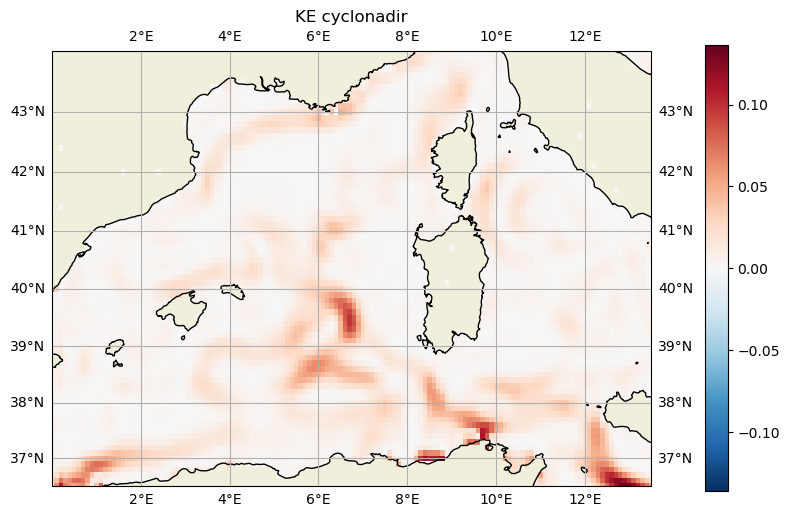

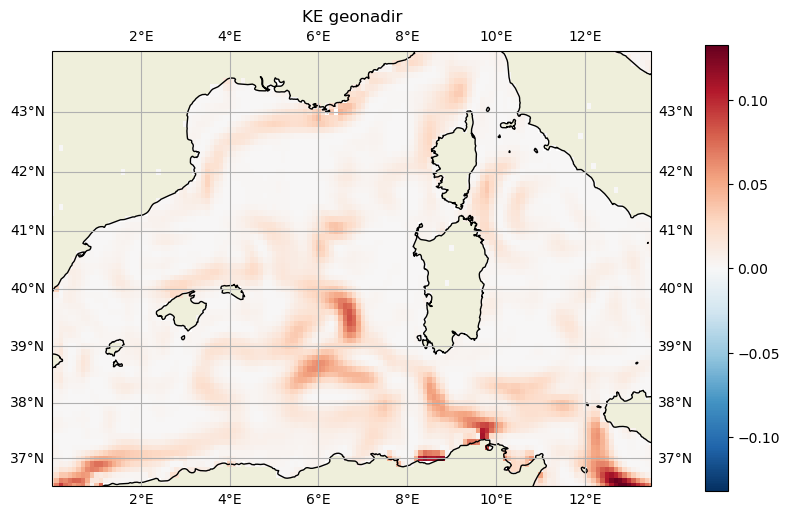

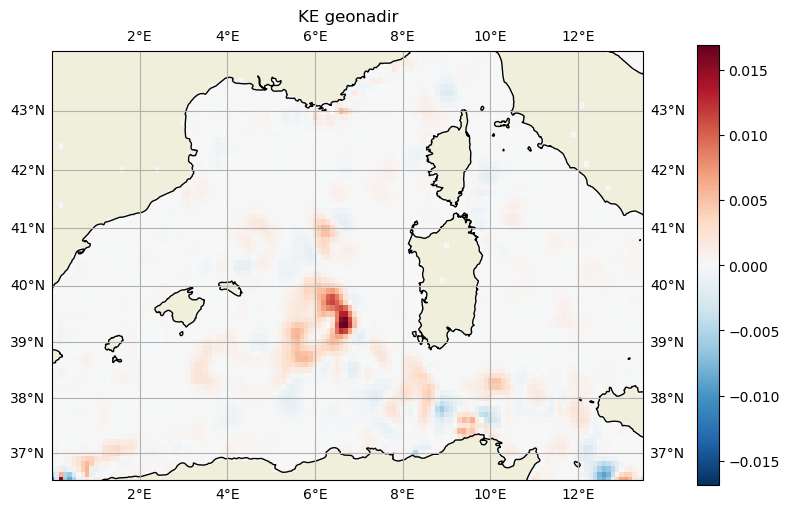

In [13]:
# NADIR

ds = ds_nadir


#select data
ds = restrain_domain(ds, *bbox)
ds = ds.sel(time=slice(start_time, end_time))

#get data
lon, lat = ds.longitude, ds.latitude

KE_var = (ds.u_var_t.mean(dim='time')**2 + ds.v_var_t.mean(dim='time')**2) 
KE_geo = (ds.u_geos_t.mean(dim='time')**2 + ds.v_geos_t.mean(dim='time')**2) 

#plot data
plot2d(lon, lat, KE_var, bbox=bbox, cmap='RdBu_r', center_bar=True, title='KE cyclonadir')
plot2d(lon, lat, KE_geo, bbox=bbox, cmap='RdBu_r', center_bar=True, title='KE geonadir')
plot2d(lon, lat, (KE_var - KE_geo), bbox=bbox, cmap='RdBu_r', center_bar=True, title='KE geonadir')

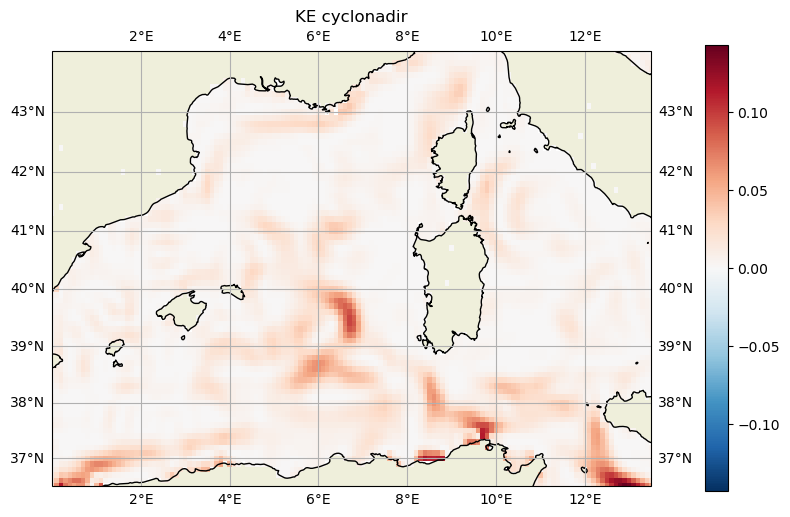

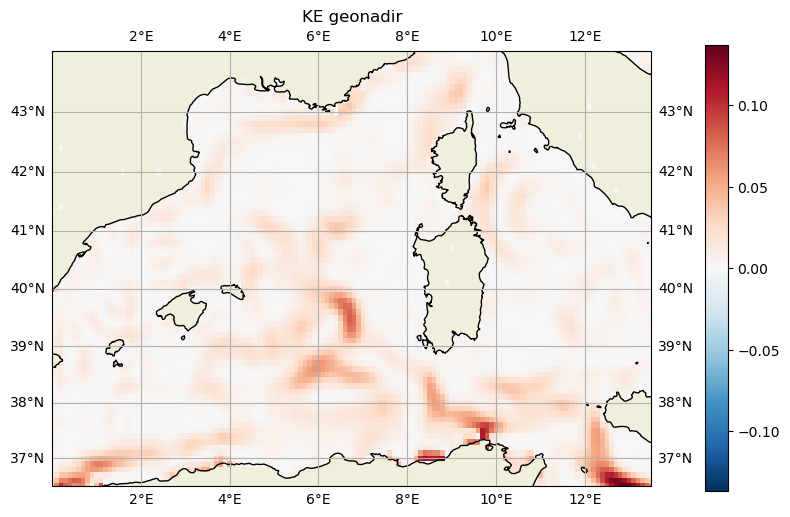

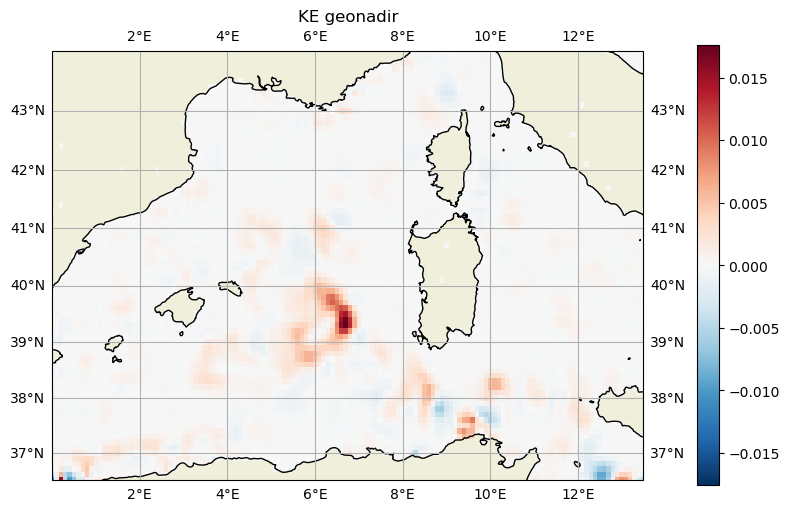

In [14]:
# SWOT

ds = ds_swot


#select data
ds = restrain_domain(ds, *bbox)
ds = ds.sel(time=slice(start_time, end_time))

#get data
lon, lat = ds.longitude, ds.latitude

KE_var = (ds.u_var_t.mean(dim='time')**2 + ds.v_var_t.mean(dim='time')**2) 
KE_geo = (ds.u_geos_t.mean(dim='time')**2 + ds.v_geos_t.mean(dim='time')**2) 

#plot data
plot2d(lon, lat, KE_var, bbox=bbox, cmap='RdBu_r', center_bar=True, title='KE cyclonadir')
plot2d(lon, lat, KE_geo, bbox=bbox, cmap='RdBu_r', center_bar=True, title='KE geonadir')
plot2d(lon, lat, (KE_var - KE_geo), bbox=bbox, cmap='RdBu_r', center_bar=True, title='KE geonadir')

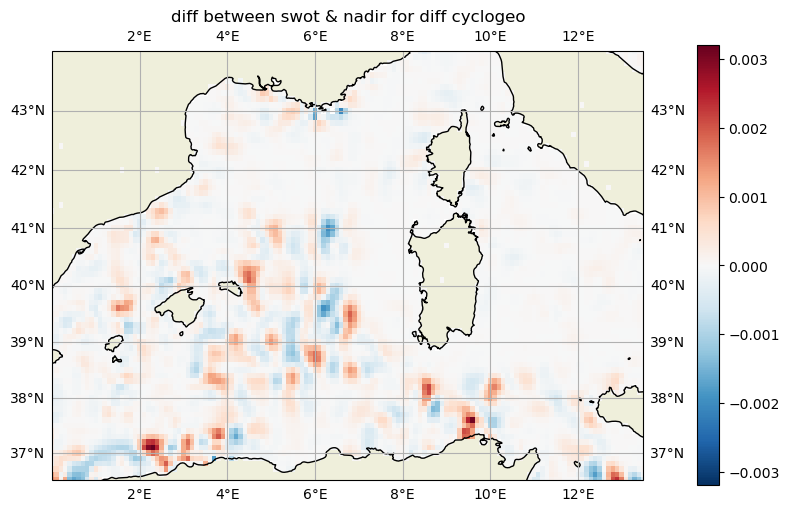

In [15]:
ds = ds_nadir
ds = restrain_domain(ds, *bbox)
ds = ds.sel(time=slice(start_time, end_time))
KE_var_nadir = ( ds.u_var_t.mean(dim='time') **2 + ds.v_var_t.mean(dim='time') **2   )
KE_geo_nadir = ( ds.u_geos_t.mean(dim='time') **2 + ds.v_geos_t.mean(dim='time') **2 )

ds = ds_swot
ds = restrain_domain(ds, *bbox)
ds = ds.sel(time=slice(start_time, end_time))
KE_var_swot = ( ds.u_var_t.mean(dim='time') **2 + ds.v_var_t.mean(dim='time') **2   )
KE_geo_swot = ( ds.u_geos_t.mean(dim='time') **2 + ds.v_geos_t.mean(dim='time') **2 )

compa = (KE_var_swot - KE_geo_swot) - (KE_var_nadir - KE_geo_nadir)   

plot2d(lon, lat, compa, bbox, cmap='RdBu_r', center_bar=True, title='diff between swot & nadir for diff cyclogeo')

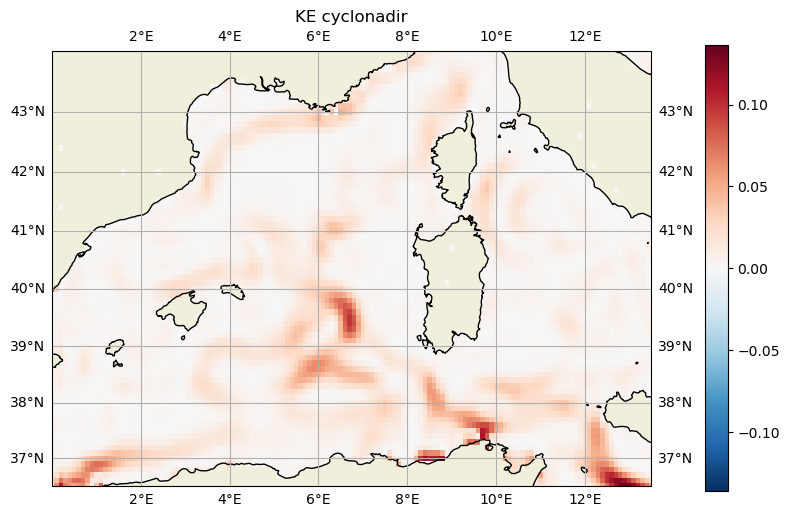

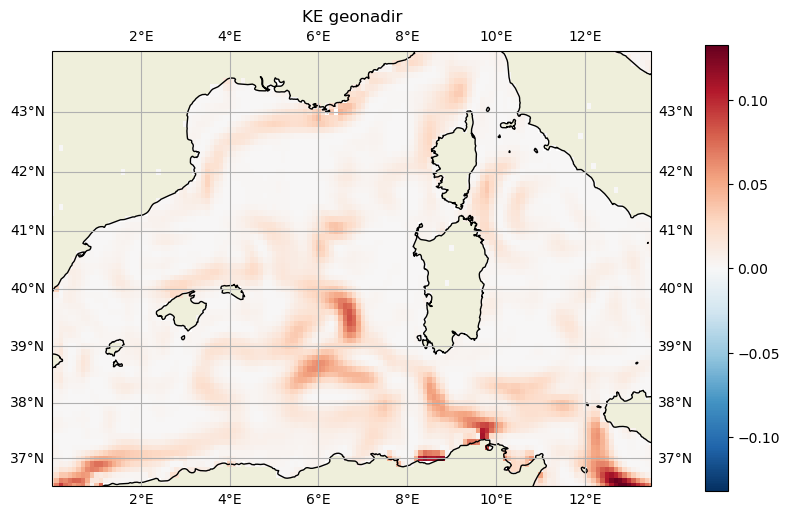

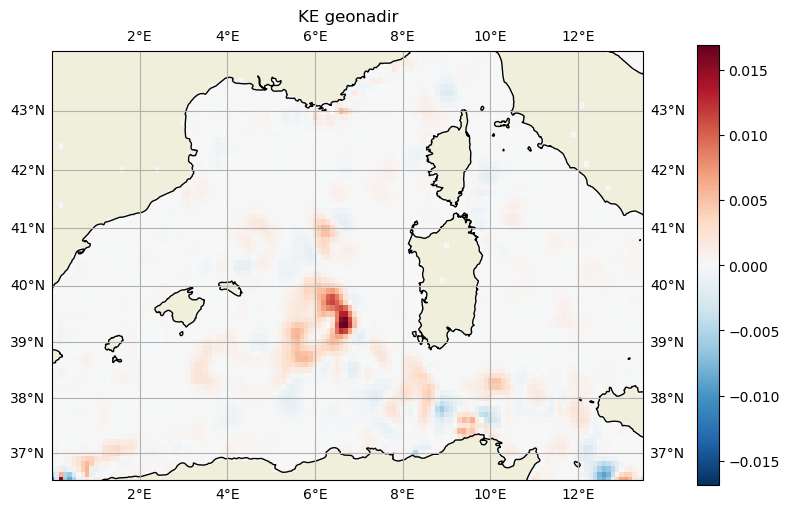

In [16]:
# NADIR

ds = ds_nadir


#select data
ds = restrain_domain(ds, *bbox)
ds = ds.sel(time=slice(start_time, end_time))

#get data
lon, lat = ds.longitude, ds.latitude

KE_var = (ds.u_var_t.mean(dim='time')**2 + ds.v_var_t.mean(dim='time')**2) 
KE_geo = (ds.u_geos_t.mean(dim='time')**2 + ds.v_geos_t.mean(dim='time')**2) 

#plot data
plot2d(lon, lat, KE_var, bbox=bbox, cmap='RdBu_r', center_bar=True, title='KE cyclonadir')
plot2d(lon, lat, KE_geo, bbox=bbox, cmap='RdBu_r', center_bar=True, title='KE geonadir')
plot2d(lon, lat, (KE_var - KE_geo), bbox=bbox, cmap='RdBu_r', center_bar=True, title='KE geonadir')